In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pyod.utils.data import generate_data
from pyod.utils.example import visualize

from bad import BAD_IForest
from pyod.models.iforest import IForest

X_train, X_test, y_train, y_test = generate_data(
    n_train=10000, n_test=10000, contamination=0.1, random_state=0
)
X = X_test.astype(np.float32)
bforest = BAD_IForest().fit(X_train)
iforest = IForest().fit(X_train)

In [2]:
%timeit BAD_IForest().fit(X_train)
%timeit IForest().fit(X_train)
%timeit bforest.decision_function(X)
%timeit iforest.decision_function(X)

216 ms ± 2.01 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
148 ms ± 234 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
54 ms ± 62.8 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
29.7 ms ± 175 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


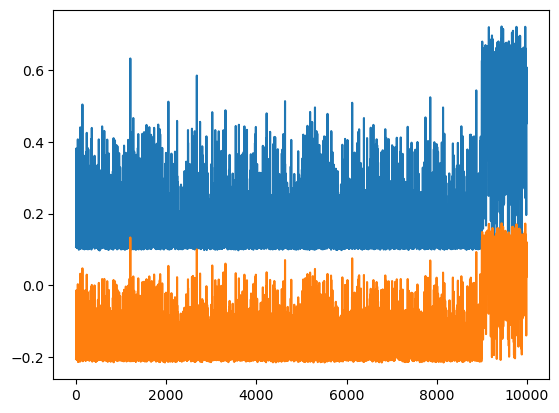

In [3]:
plt.plot(bforest.decision_function(X), label='BAD_IForest')
plt.plot(iforest.decision_function(X), label='IForest')